<a href="https://colab.research.google.com/github/BagaskaraAdhi/KlasifikasiSampah-GLCM-SVM/blob/main/2318090_UTS_GLCM%26SVM_CitraSampah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Mengkoneksikan Google Colab dengan Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Import Library yang dibutuhkan**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **3. Pengecekan Dataset & Folder**

In [ ]:
folder_proyek = '/content/drive/MyDrive/Komvis/UTS'
folder_dataset = os.path.join(folder_proyek, 'Dataset')

kategori_sampah = ['cardboard', 'glass', 'metal', 'paper', 'plastic']

print("INFO DATASET:")
total_gambar = 0
for kategori in kategori_sampah:
    subfolder = os.path.join(folder_dataset, kategori)
    if os.path.exists(subfolder):
        jumlah = len([f for f in os.listdir(subfolder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"Folder '{kategori}': {jumlah} gambar tersedia")
        total_gambar += jumlah
print(f"Total keseluruhan gambar yang akan diproses: {total_gambar} gambar\n")

INFO DATASET:
Folder 'cardboard': 403 gambar tersedia
Folder 'glass': 501 gambar tersedia
Folder 'metal': 410 gambar tersedia
Folder 'paper': 594 gambar tersedia
Folder 'plastic': 482 gambar tersedia
Total keseluruhan gambar yang akan diproses: 2390 gambar



# **4. Menampilkan 5 Data Original dari Masing-Masing Folder**

Menampilkan Sample 5 Gambar ORIGINAL per Kategori...


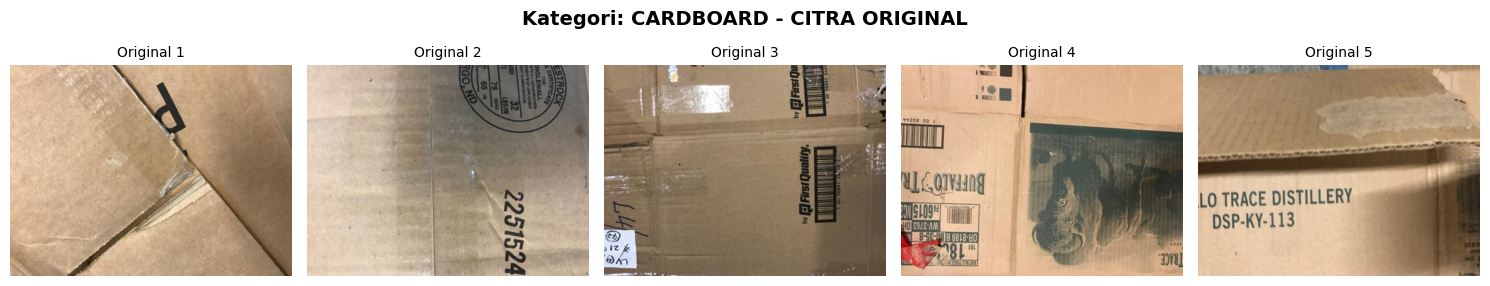

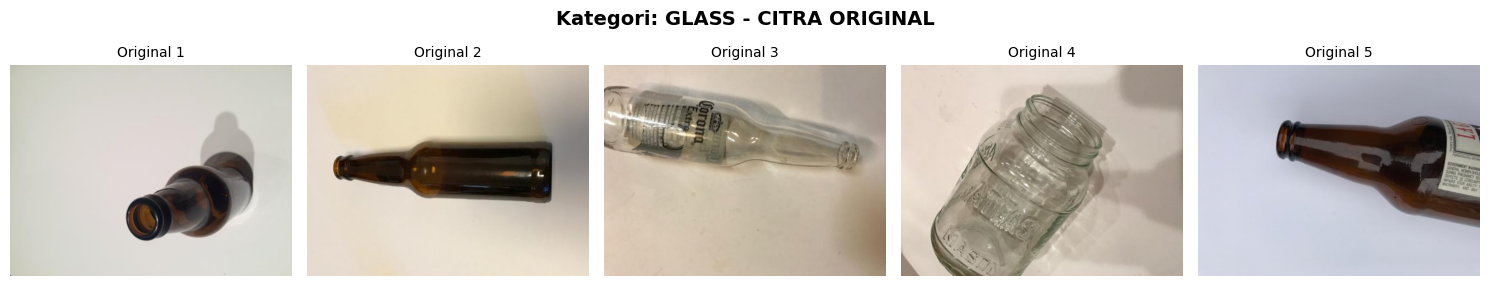

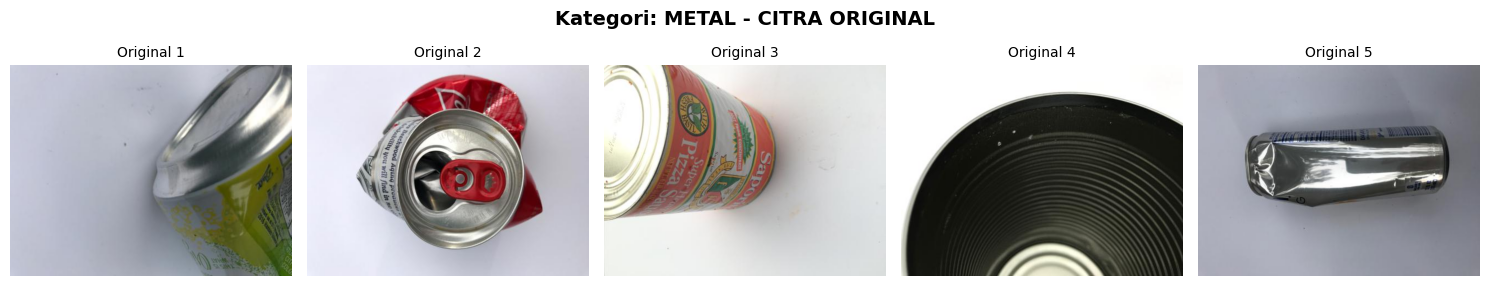

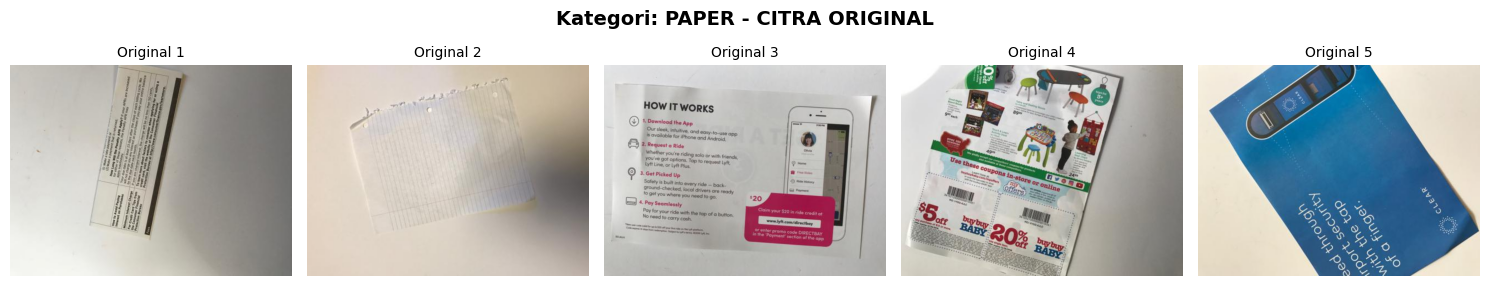

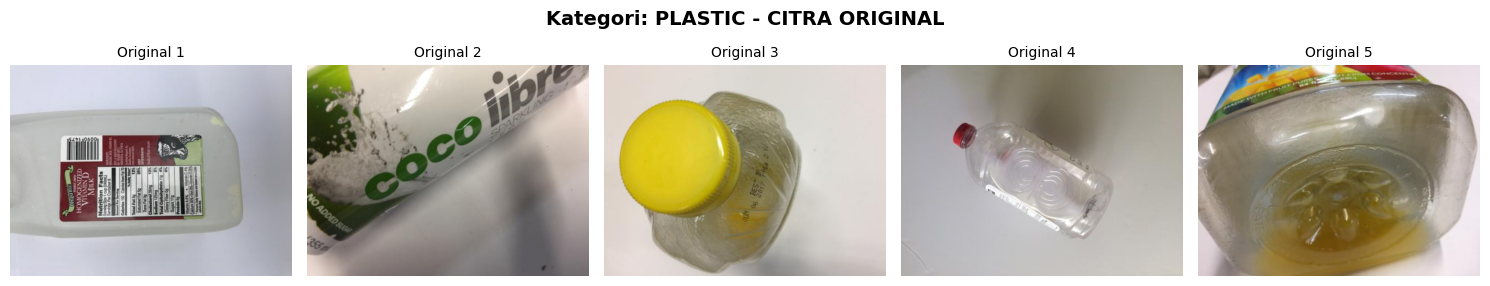

In [ ]:
print("Menampilkan Sample 5 Gambar ORIGINAL per Kategori...")
for kategori in kategori_sampah:
    subfolder_path = os.path.join(folder_dataset, kategori)
    if not os.path.exists(subfolder_path): continue

    # Mengambil 5 gambar pertama
    files = [f for f in os.listdir(subfolder_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))][:5]

    fig_orig, axes_orig = plt.subplots(1, 5, figsize=(15, 3))
    fig_orig.suptitle(f"Kategori: {kategori.upper()} - CITRA ORIGINAL", fontsize=14, fontweight='bold')

    for i, file_name in enumerate(files):
        img_path = os.path.join(subfolder_path, file_name)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue

        # Konversi BGR (OpenCV) ke RGB (Matplotlib) agar warna tidak klise
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        axes_orig[i].imshow(img_rgb)
        axes_orig[i].set_title(f"Original {i+1}", fontsize=10)
        axes_orig[i].axis('off')

    plt.tight_layout()
    plt.show()

# **5. Menampilkan 5 Data Grayscale dari Masing-Masing Folder**


Menampilkan Sample 5 Gambar GRAYSCALE (Pre-processing) per Kategori...


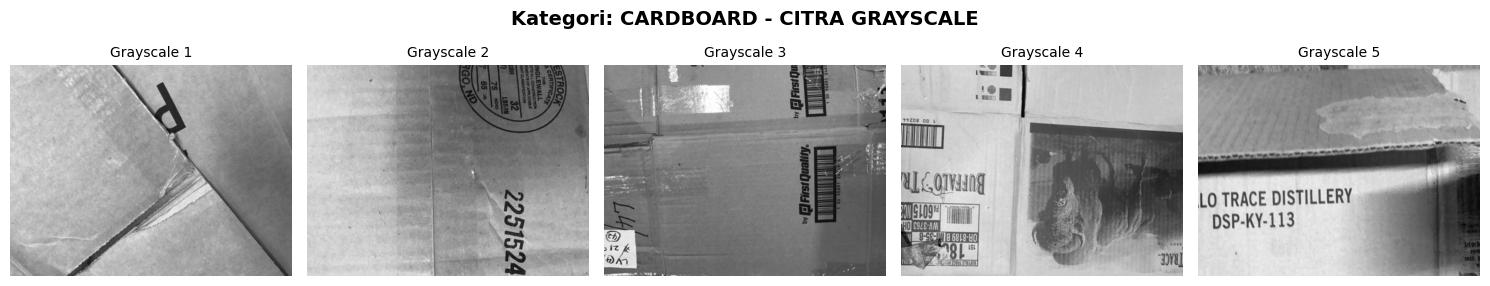

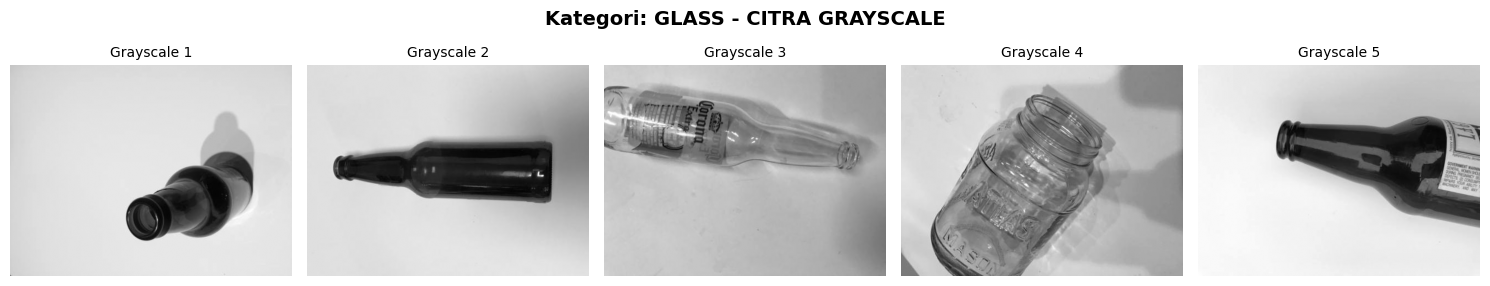

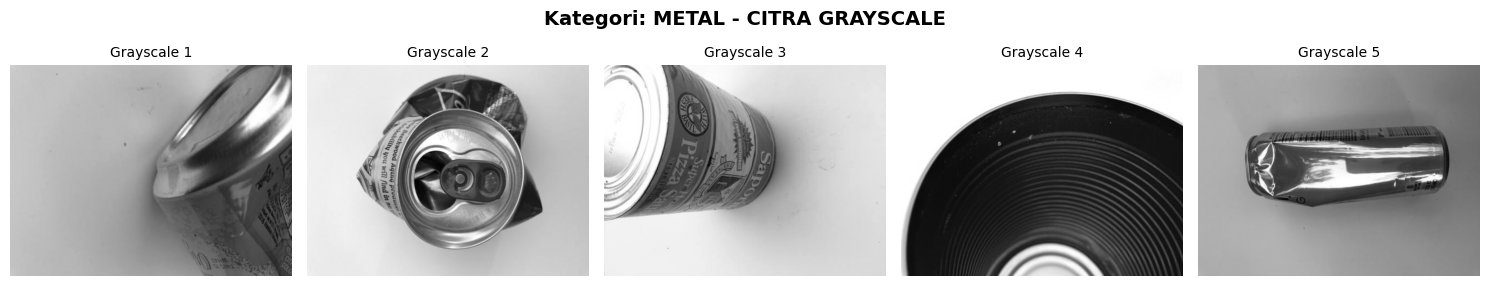

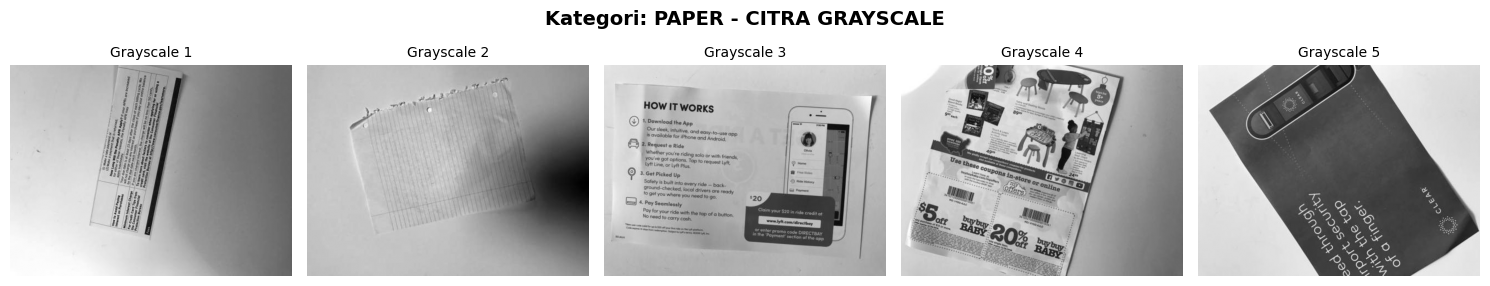

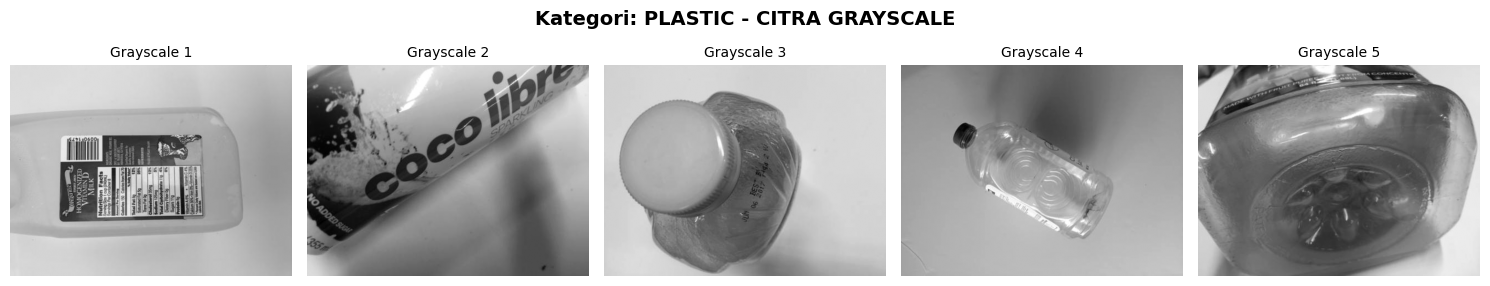

In [ ]:
print("\nMenampilkan Sample 5 Gambar GRAYSCALE (Pre-processing) per Kategori...")
for kategori in kategori_sampah:
    subfolder_path = os.path.join(folder_dataset, kategori)
    if not os.path.exists(subfolder_path): continue

    # Mengambil 5 gambar pertama (sama seperti di atas)
    files = [f for f in os.listdir(subfolder_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))][:5]

    fig_gray, axes_gray = plt.subplots(1, 5, figsize=(15, 3))
    fig_gray.suptitle(f"Kategori: {kategori.upper()} - CITRA GRAYSCALE", fontsize=14, fontweight='bold')

    for i, file_name in enumerate(files):
        img_path = os.path.join(subfolder_path, file_name)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue

        # Konversi BGR ke Grayscale
        img_gray_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        axes_gray[i].imshow(img_gray_cv, cmap='gray')
        axes_gray[i].set_title(f"Grayscale {i+1}", fontsize=10)
        axes_gray[i].axis('off')

    plt.tight_layout()
    plt.show()

# **6. Ekstrasi Fitur GLCM**

In [ ]:
print(f"\nMemulai Ekstraksi Fitur GLCM untuk {total_gambar} Citra...")
print("(Mohon tunggu, proses ini mungkin memakan waktu beberapa menit karena jumlah data yang besar)")

nilai_fitur = []

for kategori in kategori_sampah:
    subfolder_path = os.path.join(folder_dataset, kategori)
    if not os.path.exists(subfolder_path): continue

    files = [f for f in os.listdir(subfolder_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    # Memproses SEMUA file
    for file_name in files:
        img_path = os.path.join(subfolder_path, file_name)
        image = cv2.imread(img_path)
        if image is None: continue

        # Konversi warna BGR ke Grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Ekstraksi matriks tekstur (Jarak 1 piksel, 4 arah sudut)
        glcm = graycomatrix(gray, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)

        # Hitung rata-rata 5 properti tekstur
        contrast = graycoprops(glcm, 'contrast').mean()
        dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()
        energy = graycoprops(glcm, 'energy').mean()
        correlation = graycoprops(glcm, 'correlation').mean()

        nilai_fitur.append([file_name, kategori, contrast, dissimilarity, homogeneity, energy, correlation])


Memulai Ekstraksi Fitur GLCM untuk 2390 Citra...
(Mohon tunggu, proses ini mungkin memakan waktu beberapa menit karena jumlah data yang besar)


# **7. Simpan Hasil Excel**

In [ ]:
nama_kolom = ['Nama File', 'Kategori', 'Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation']
df = pd.DataFrame(nilai_fitur, columns=nama_kolom)

path_excel = os.path.join(folder_proyek, 'Bagaskara2318090_UTS_SVM_FULL.xlsx')
df.to_excel(path_excel, index=False)
print(f"\nEkstraksi selesai! Total Data Berhasil Diekstrak: {len(df)} baris.")
print(f"File dataset disimpan di Drive: {path_excel}")


Ekstraksi selesai! Total Data Berhasil Diekstrak: 2390 baris.
File dataset disimpan di Drive: /content/drive/MyDrive/Komvis/UTS/Bagaskara2318090_UTS_SVM_FULL.xlsx


# **8. Exploratory Data Analysis (Visualisasi EDA)**

Menampilkan Distribusi Data (EDA)...


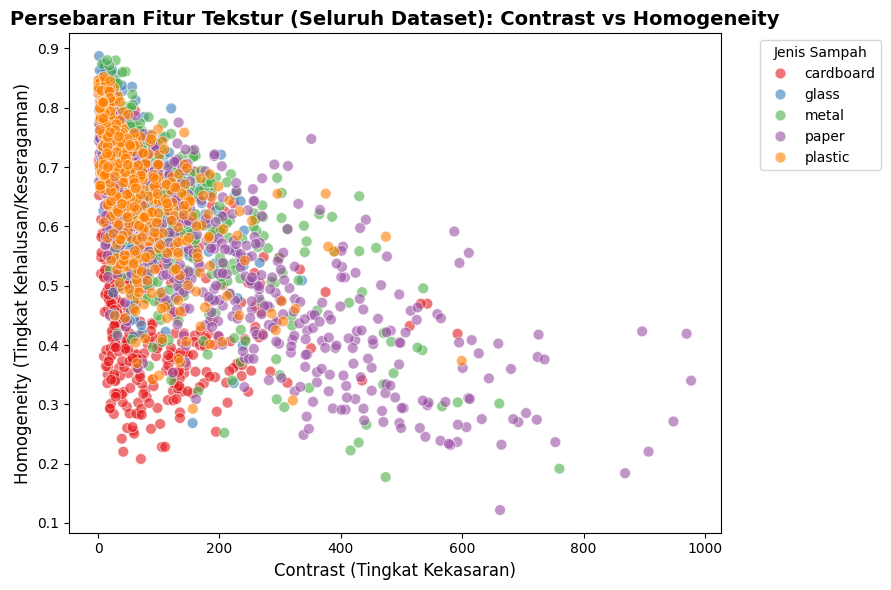

In [ ]:
print("Menampilkan Distribusi Data (EDA)...")
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Contrast', y='Homogeneity', hue='Kategori', data=df, palette='Set1', s=60, alpha=0.6)
plt.title("Persebaran Fitur Tekstur (Seluruh Dataset): Contrast vs Homogeneity", fontsize=14, fontweight='bold')
plt.xlabel("Contrast (Tingkat Kekasaran)", fontsize=12)
plt.ylabel("Homogeneity (Tingkat Kehalusan/Keseragaman)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Jenis Sampah")
plt.tight_layout()
plt.show()

# **9. Split & Normalisasi Data**

In [ ]:
print("\nMempersiapkan Data untuk Machine Learning...")
X = df[['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation']]
y = df['Kategori']

# Membagi dataset: 80% Latih (Training), 20% Uji (Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Training) : {len(X_train)} gambar")
print(f"Jumlah Data Uji (Testing)    : {len(X_test)} gambar\n")

# Normalisasi data (Standardisasi) agar SVM bekerja maksimal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Mempersiapkan Data untuk Machine Learning...
Jumlah Data Latih (Training) : 1912 gambar
Jumlah Data Uji (Testing)    : 478 gambar



# **10. Training Model SVM (Support Vector Machine)**

In [ ]:
print("Melatih Model Support Vector Machine (SVM)...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

Melatih Model Support Vector Machine (SVM)...


SVC(random_state=42)

# **11. Evaluasi Hasil & Confusion Matrix**

PROSES SELESAI! Akurasi Model SVM: 55.23%

LAPORAN KLASIFIKASI (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

   cardboard       0.78      0.70      0.74        81
       glass       0.42      0.71      0.53       100
       metal       0.57      0.35      0.44        82
       paper       0.56      0.59      0.57       119
     plastic       0.63      0.39      0.48        96

    accuracy                           0.55       478
   macro avg       0.59      0.55      0.55       478
weighted avg       0.58      0.55      0.55       478



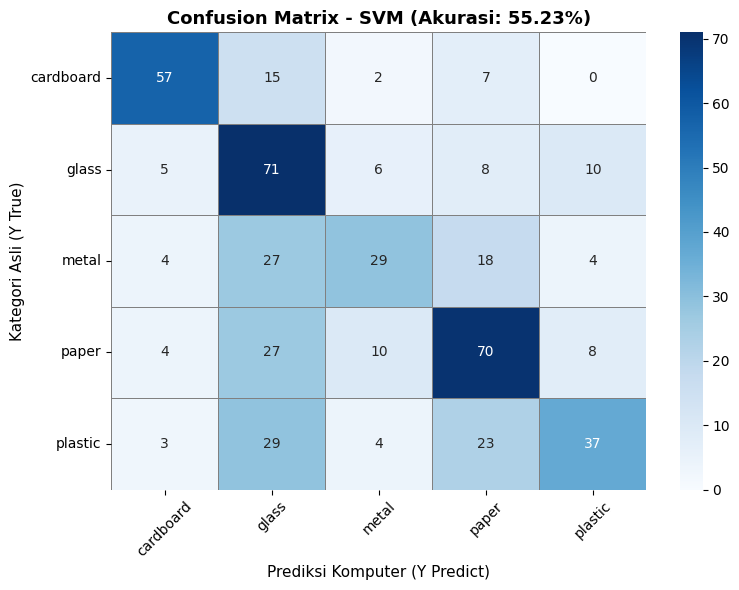

In [ ]:
y_pred = svm_model.predict(X_test_scaled)

akurasi = accuracy_score(y_test, y_pred)
print(f"PROSES SELESAI! Akurasi Model SVM: {akurasi * 100:.2f}%\n")

print("LAPORAN KLASIFIKASI (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=kategori_sampah)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=kategori_sampah, yticklabels=kategori_sampah, linewidths=0.5, linecolor='gray')
plt.title(f'Confusion Matrix - SVM (Akurasi: {akurasi * 100:.2f}%)', fontsize=13, fontweight='bold')
plt.xlabel('Prediksi Komputer (Y Predict)', fontsize=11)
plt.ylabel('Kategori Asli (Y True)', fontsize=11)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()